# Previsão de Séries Temporais: Clima em Szeged, Hungria

Neste notebook, utilizaremos o dataset **Weather in Szeged 2006-2016** (disponível no Kaggle: `muthuj7/weather-dataset`).

A base possui medições de temperatura, umidade, velocidade do vento, entre outras, coletadas de hora em hora. Nosso objetivo será aplicar técnicas de previsão apresentadas na disciplina para prever a temperatura futura com base em dados passados. Usaremos 80% dos dados para treinamento e o restante para teste.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

import kagglehub
import os

In [2]:
# Download dataset via kagglehub
path = kagglehub.dataset_download("muthuj7/weather-dataset")
print("Diretório do dataset:", path)


100%|██████████| 2.23M/2.23M [00:00<00:00, 28.4MB/s]

Extracting files...


Diretório do dataset: /root/.cache/kagglehub/datasets/muthuj7/weather-dataset/versions/1


In [3]:
csv_path = os.path.join(path, "weatherHistory.csv")
df = pd.read_csv(csv_path, parse_dates=["Formatted Date"], index_col="Formatted Date").sort_index()

split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx]
test = df.iloc[split_idx:]


In [4]:
def extract_features_and_target(dataframe):
    # Selecionando algumas colunas contínuas para facilitar
    cols = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)']
    features = dataframe[cols].to_numpy()
    target = dataframe['Temperature (C)'].to_numpy()
    return features, target


In [5]:
raw_data, temperature = extract_features_and_target(train)
raw_test_data, test_temperature = extract_features_and_target(test)


In [6]:
raw_data.shape

(77162, 4)

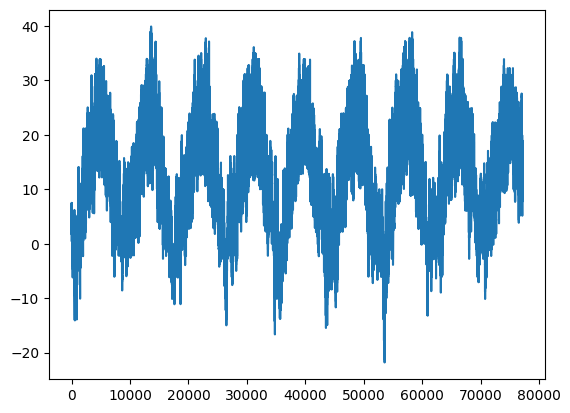

In [7]:
plt.plot(temperature)
plt.show()

### Justificativa dos Parâmetros
Os parâmetros abaixo geram o dataset supervisionado a partir do array contínuo da série temporal:
* **sequence_length = 30**: Como os dados (neste caso, podem ser diários ou horários) possuem variações de curto prazo, olhar para os 30 passos anteriores nos dá contexto suficiente para a rede aprender tendências recentes e padrões.
* **forecast_horizon = 7**: O modelo fará previsões olhando 7 passos de tempo à frente, oferecendo uma estimativa útil para curto prazo.
* **sampling_rate = 1**: Utilizaremos todas as amostras disponíveis dentro da janela de `sequence_length`, sem saltar nenhuma, para não perder informações.
* **delay**: É calculado com base na janela somado ao horizonte para alinhar adequadamente os alvos (targets) com a janela de entrada correspondente.

In [8]:
sampling_rate = 1
sequence_length = 30
forecast_horizon = 7
delay = sampling_rate * (sequence_length + forecast_horizon + 1)  # 38
batch_size = 256

N = len(raw_data)
max_index = N - delay

num_train_samples = int(max_index * 0.8)
# val começa onde o train termina, até o fim dos dados de treino
num_val_samples = max_index - num_train_samples
num_test_samples = len(raw_test_data)

print(f"N = {N}")
print(f"delay = {delay}")
print(f"max_index (len(data)) = {max_index}")

print('num_train_samples (80%):', num_train_samples)
print('num_val_samples (20%):', num_val_samples)
print('num_test_samples:', num_test_samples)

N = 77162
delay = 38
max_index (len(data)) = 77124
num_train_samples (80%): 61699
num_val_samples (20%): 15425
num_test_samples: 19291


In [9]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

# não recalcula só aplica
raw_test_data -= mean
raw_test_data /= std

In [10]:
from tensorflow import keras



train_dataset = keras.utils.timeseries_dataset_from_array(
    data=raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    end_index=num_train_samples
)
val_dataset = keras.utils.timeseries_dataset_from_array(
    data=raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=max_index - 1
)

test_max = len(raw_test_data) - delay
test_dataset = keras.utils.timeseries_dataset_from_array(
    data=raw_test_data[:-delay],
    targets=test_temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=False,
    batch_size=batch_size,
    start_index=0,
    end_index=test_max-1
)

## Técnica Ingênua (Naïve) - Baseline
A técnica Naïve assume que o valor futuro será exatamente igual ao último valor observado. Isso servirá como uma base de comparação (baseline) para os nossos modelos complexos. Se um modelo de deep learning não for capaz de bater essa métrica, ele não está aprendendo padrões úteis.

In [11]:
def evaluate_naive_method(dataset):
  total_abs_err = 0
  samples_seen = 0
  for samples, targets in dataset:
    preds = samples[:, -1, 1] * std[1] + mean[1]
    total_abs_err += np.sum(np.abs(preds - targets))
    samples_seen += samples.shape[0]
  return total_abs_err / samples_seen

print("Validation MAE (naive method):", evaluate_naive_method(val_dataset))
print("Test MAE (naive method):", evaluate_naive_method(test_dataset))

Validation MAE (naive method): 12.9501442026632
Test MAE (naive method): 11.367231557104626


In [14]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
# Use Reshape instead of Flatten
x = layers.Reshape((-1, sequence_length * raw_data.shape[-1]))(inputs)
x = layers.Dense(16, activation='relu')(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("szeged_dense.keras",
                                    save_best_only=True)
]

model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

model = keras.models.load_model("szeged_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - loss: 137.9716 - mae: 9.5119 - val_loss: 93.2818 - val_mae: 7.9009
Epoch 2/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - loss: 103.7039 - mae: 8.3863 - val_loss: 84.1092 - val_mae: 7.5298
Epoch 3/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - loss: 100.9931 - mae: 8.2962 - val_loss: 81.9523 - val_mae: 7.4385
Epoch 4/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - loss: 100.1491 - mae: 8.2678 - val_loss: 81.2251 - val_mae: 7.4091
Epoch 5/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - loss: 99.6743 - mae: 8.2519 - val_loss: 82.3322 - val_mae: 7.4612
Epoch 6/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - loss: 99.3042 - mae: 8.2404 - val_loss: 80.8778 - val_mae: 7.3976
Epoch 7/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - loss: 99.0043 - mae: 8.2297 - val_loss: 80.3628 - val_mae: 7.3751
Epoch 8/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - loss: 98.7476 - mae: 8.2211 - val_loss: 80.0189 - val_mae: 7.3605
Epoch 9/10
241/241 ━

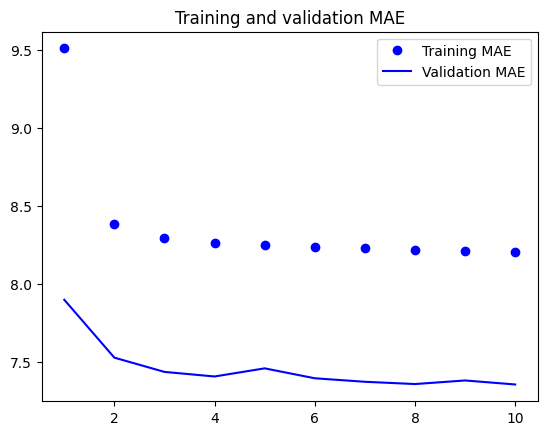

In [15]:
import matplotlib.pyplot as plt
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)
plt.figure
plt.plot(epochs, loss, 'bo', label='Training MAE')
plt.plot(epochs, val_loss, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.legend()
plt.show()

## 1d convolutional model

In [18]:

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation='relu', padding='same')(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation='relu', padding='same')(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("szeged_conv.keras",
                                    save_best_only=True)
]

model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model("szeged_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/step - loss: 35.3302 - mae: 4.1833 - val_loss: 11.4436 - val_mae: 2.6850
Epoch 2/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - loss: 13.0843 - mae: 2.7946 - val_loss: 9.4603 - val_mae: 2.3941
Epoch 3/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - loss: 10.1585 - mae: 2.4794 - val_loss: 8.4609 - val_mae: 2.2711
Epoch 4/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - loss: 8.8578 - mae: 2.3147 - val_loss: 7.8725 - val_mae: 2.1879
Epoch 5/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - loss: 8.3218 - mae: 2.2410 - val_loss: 8.6688 - val_mae: 2.3507
Epoch 6/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - loss: 7.9920 - mae: 2.1929 - val_loss: 7.5499 - val_mae: 2.1619
Epoch 7/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - loss: 7.7723 - mae: 2.1616 - val_loss: 7.2108 - val_mae: 2.1009
Epoch 8/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - loss: 7.5512 - mae: 2.1267 - val_loss: 7.3423 - val_mae: 2.1224
Epoch 9/10
241/241 ━━━━━━━━━━━━━━━━━

## LSTM

In [20]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs=inputs, outputs=outputs)

callbacks = [keras.callbacks.ModelCheckpoint("szeged_lstm.keras", save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset, epochs=10, validation_data=val_dataset, callbacks=callbacks)
model = keras.models.load_model("szeged_lstm.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - loss: 151.5113 - mae: 9.7174 - val_loss: 97.1017 - val_mae: 7.6930
Epoch 2/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - loss: 71.5247 - mae: 6.2576 - val_loss: 50.8383 - val_mae: 5.2601
Epoch 3/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - loss: 39.3498 - mae: 4.4798 - val_loss: 26.5153 - val_mae: 3.7042
Epoch 4/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - loss: 21.7522 - mae: 3.3319 - val_loss: 15.0701 - val_mae: 2.8781
Epoch 5/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - loss: 13.3361 - mae: 2.7098 - val_loss: 9.9834 - val_mae: 2.4130
Epoch 6/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - loss: 9.8502 - mae: 2.3974 - val_loss: 8.3431 - val_mae: 2.2424
Epoch 7/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - loss: 8.5579 - mae: 2.2525 - val_loss: 7.7166 - val_mae: 2.1563
Epoch 8/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - loss: 8.0003 - mae: 2.1775 - val_loss: 7.5471 - val_mae: 2.1225
Epoch 9/10
241/241 ━━━━━━━━━━━

In [21]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1)(x)
model = keras.Model(inputs, output)

callbacks = [keras.callbacks.ModelCheckpoint("szeged_lstm_dropout.keras", save_best_only=True)]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset, epochs=10, validation_data=val_dataset, callbacks=callbacks)
model = keras.models.load_model("szeged_lstm_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 28s 105ms/step - loss: 86.4644 - mae: 6.9845 - val_loss: 33.4894 - val_mae: 4.3523
Epoch 2/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 22s 92ms/step - loss: 32.1303 - mae: 4.2985 - val_loss: 13.9539 - val_mae: 2.9025
Epoch 3/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - loss: 22.5136 - mae: 3.6525 - val_loss: 10.0871 - val_mae: 2.4867
Epoch 4/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - loss: 19.7463 - mae: 3.4209 - val_loss: 9.2767 - val_mae: 2.3880
Epoch 5/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 22s 91ms/step - loss: 18.4601 - mae: 3.3116 - val_loss: 8.3170 - val_mae: 2.2678
Epoch 6/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 41s 93ms/step - loss: 17.6388 - mae: 3.2296 - val_loss: 8.4064 - val_mae: 2.2526
Epoch 7/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - loss: 17.0371 - mae: 3.1824 - val_loss: 7.7230 - val_mae: 2.1633
Epoch 8/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 22s 90ms/step - loss: 16.4728 - mae: 3.1184 - val_loss: 7.6367 - val_mae: 2.1441
Epoch 9/10
241/241 ━━━━━━━━━

## Bi LSTM

In [22]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs=inputs, outputs=outputs)

callbacks = [keras.callbacks.ModelCheckpoint("szeged_lstm_bidirecional.keras", save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset, epochs=10, validation_data=val_dataset, callbacks=callbacks)
model = keras.models.load_model("szeged_lstm_bidirecional.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 25s 87ms/step - loss: 107.0858 - mae: 7.8341 - val_loss: 41.9384 - val_mae: 4.8206
Epoch 2/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - loss: 26.7019 - mae: 3.7667 - val_loss: 13.4429 - val_mae: 2.7663
Epoch 3/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - loss: 11.3505 - mae: 2.5774 - val_loss: 8.1497 - val_mae: 2.2284
Epoch 4/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 21s 87ms/step - loss: 8.4516 - mae: 2.2551 - val_loss: 7.5343 - val_mae: 2.1609
Epoch 5/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - loss: 7.7047 - mae: 2.1491 - val_loss: 7.0291 - val_mae: 2.0713
Epoch 6/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 21s 86ms/step - loss: 7.3242 - mae: 2.0941 - val_loss: 6.6770 - val_mae: 2.0121
Epoch 7/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - loss: 7.0390 - mae: 2.0494 - val_loss: 6.7358 - val_mae: 2.0293
Epoch 8/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 22s 85ms/step - loss: 6.8477 - mae: 2.0180 - val_loss: 6.5517 - val_mae: 1.9842
Epoch 9/10
241/241 ━━━━━━━━━━━━━━━